# 02 - Pipeline

## Objetivo del notebook

Este notebook entrena, compara y audita modelos multietiqueta para sugerir articulos candidatos del Convenio Europeo de Derechos Humanos a partir del texto de hechos. La salida no es una clase unica: cada caso se representa como un vector de diez decisiones binarias, una por articulo.

El notebook esta organizado como una practica reproducible: cada fase tiene una seccion localizable, una entrada clara, una transformacion concreta y una salida verificable. Las tablas visibles se mantienen cortas; las tablas completas se guardan como CSV en `artifacts/metrics/`. Las comparaciones importantes se interpretan con figuras dentro del notebook.

## Como leerlo

1. **Preparacion**: carga de splits y matriz multietiqueta.
2. **Diseno del pipeline**: mapa operativo con indice para localizar cada paso.
3. **Entrenamiento modular**: una celda por modelo, con tabla corta y grafica.
4. **Evaluacion visual**: comparacion macro/micro, matrices de error, ROC y Precision-Recall.
5. **Artefactos**: modelos, metricas, figuras y predicciones persistidas para notebooks posteriores.

## Criterio metodologico

El modelo principal es **TF-IDF + Regresion Logistica One-vs-Rest con umbrales por etiqueta**, porque combina rendimiento razonable, reproducibilidad y explicabilidad. Se compara con un baseline frecuente, SVM lineal y SVD+MLP para separar mejora real, margen lineal y frontera no lineal ligera.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_02_modeling_v2.png)

**Lectura del esquema.** La imagen resume el modelado: TF-IDF como representacion comun, comparacion de LogReg OVR, SVM y SVD+MLP, ajuste de umbrales y metricas multietiqueta. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.



La tabla actua como indice tecnico del notebook. La columna **Seccion** permite localizar rapidamente donde se implementa cada paso.

| Seccion | Paso | Entrada | Transformacion | Salida |  |
|---|---|---|---|---|---|
|  1 | Carga desde SQLite | `cases.text_full` y `case_labels` | Union con la matriz multietiqueta `Y` | `frames['train']`, `frames['validation']`, `frames['test']` | Mantiene separados texto, etiquetas y protocolo experimental. |
|  2.1 | Soporte por etiqueta | Splits oficiales y columnas de articulos | Conteo de positivos por articulo y split | Tabla corta de soporte | Anticipa desbalanceo y dificultad por etiqueta. |
|  3.6 | Vectorizacion TF-IDF | Lista de textos reales de train | Unigramas y bigramas ponderados por frecuencia inversa | `X_train`, `X_val`, `X_test` dispersas | Representa texto largo sin truncar y permite interpretar terminos. |
|  3.6.1 | Baseline frecuente | `Y_train` | Seleccion del articulo mayoritario | Prediccion constante | Comprueba que el problema no se resuelve con una regla trivial. |
|  3.6.2 | Logistic Regression OVR | `X_train`, `Y_train` | Diez clasificadores binarios independientes | Scores probabilisticos por articulo | Da scores calibrables y coeficientes auditables. |
|  3.6.3 | SVM lineal OVR | `X_train`, `Y_train` | Diez hiperplanos de margen maximo | Etiquetas binarias y scores de decision | Comparador fuerte para alta dimensionalidad TF-IDF. |
|  3.6.4 | SVD + MLP | `X_train`, `Y_train` | Reduccion densa + red neuronal de una capa | Scores por articulo y curva de loss | Comparacion no lineal. |
|  3.6.2 y 9 | Umbrales por etiqueta | Scores de validation | Busqueda del mejor F1 por articulo | `tau_j` por articulo | Evita un 0.5 global que perjudica etiquetas raras. |
|  3.6.5 | Comparacion validation/test | `Y_split`, `Y_pred` | Macro-F1 y micro-F1 | Figura comparativa y CSV completo | Muestra rendimiento. |
|  4 | Auditoria de errores | `Y_test`, `Y_pred_test` | Conteo FP/FN por modelo y articulo | Heatmaps y CSV TP/FP/FN/TN | Permite ver donde falla cada modelo. |
|  5 | Curvas ROC/PR | Scores continuos en test | Curvas micro-promediadas con Matplotlib | Figura ROC + Precision-Recall | Evalua ranking de confianza, no solo decision binaria. |
| 3.6.5 y 10 | Persistencia | Modelos, metricas y predicciones | Escritura en disco y SQLite | `artifacts/models/`, `artifacts/metrics/`, `predictions` | Hace reproducible el analisis y alimenta notebooks posteriores. |

La entrada final del sistema es siempre texto real de un caso. La salida final del modelo principal es un vector de diez decisiones binarias junto con diez scores continuos que permiten ordenar confianza, ajustar umbrales y explicar errores.


In [1]:
import json, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image as IPImage
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)


## 1. Datos de modelado

Se reconstruyen los splits oficiales desde SQLite. Esta seccion prepara la base comun del modelado: texto completo, identificadores de caso y columnas binarias por articulo.

In [2]:
pu.materialize_database(force=False)
frames = pu.train_validation_test_frames()
for split, df in frames.items():
    print(split, df.shape)
    display(df[['case_id','split','n_tokens'] + pu.ARTICLE_CODES].head(3))


train (9000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_train_000000,train,7014,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_train_000001,train,2788,0,0,0,1,0,0,0,0,1,1
2,ecthr_task_b_train_000002,train,1380,0,0,0,1,0,0,0,0,0,0


validation (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_validation_000000,validation,310,0,0,0,0,1,0,0,0,0,0
1,ecthr_task_b_validation_000001,validation,1260,0,1,0,0,0,0,0,0,0,0
2,ecthr_task_b_validation_000002,validation,2116,0,1,0,1,0,0,0,0,0,0


test (1000, 17)


,case_id,split,n_tokens,2,3,5,6,8,9,10,11,14,P1-1
0,ecthr_task_b_test_000000,test,4774,0,0,0,0,0,0,1,0,0,0
1,ecthr_task_b_test_000001,test,1073,0,0,0,0,1,0,0,0,0,0
2,ecthr_task_b_test_000002,test,302,0,0,0,1,0,0,0,0,0,0


## 2. Formulacion One-vs-Rest

El problema se formula como diez decisiones binarias independientes: para cada articulo se aprende si esta presente o no en el caso. Esto evita convertir indebidamente una tarea multietiqueta en multiclase.

## 2.1 Conteo de casos por tipo de artículo y split


In [3]:
label_support = frames['train'][pu.ARTICLE_CODES].sum().rename('train_positives').rename_axis('article_code').reset_index()
label_support['validation_positives'] = frames['validation'][pu.ARTICLE_CODES].sum().values
label_support['test_positives'] = frames['test'][pu.ARTICLE_CODES].sum().values
display(label_support)


,article_code,train_positives,validation_positives,test_positives
0,2,623,75,76
1,3,1740,236,234
2,5,1623,219,196
3,6,5437,394,394
4,8,1056,153,188
5,9,81,9,11
6,10,441,64,106
7,11,162,39,43
8,14,444,34,32
9,P1-1,1558,168,155


## 3. Entrenamiento y comparacion


### 3.1 Imports, paths y artefactos

Se importan los estimadores y se centralizan las rutas de modelos. Todos los objetos entrenados se guardan en `artifacts/models/` para no reentrenar en cada ejecucion.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, jaccard_score,
    precision_recall_curve, roc_auc_score, roc_curve, auc
)
import joblib

MODEL_PATHS = {
    'vectorizer': pu.MODELS / 'notebook_tfidf_vectorizer.joblib',
    'logreg': pu.MODELS / 'notebook_logreg_ovr.joblib',
    'svm': pu.MODELS / 'notebook_svm_ovr.joblib',
    'mlp': pu.MODELS / 'notebook_svd_mlp.joblib',
    'thresholds': pu.MODELS / 'notebook_thresholds.json',
}



### 3.2 Umbrales y persistencia de predicciones

Estas funciones separan dos responsabilidades: ajustar umbrales por articulo en validation y guardar predicciones por caso en SQLite para auditoria posterior.

In [5]:

def tune_thresholds(y_true, scores, grid=None):
    """Ajusta un umbral de decision por articulo usando F1 en validacion.

    Entrada:
        y_true: matriz binaria real de validacion.
        scores: matriz de scores/probabilidades por articulo.
        grid: valores candidatos de umbral. Si es `None`, usa 0.10..0.90.

    Salida:
        Vector `tau` con un umbral por columna/articulo.
    """
    from sklearn.metrics import f1_score

    if grid is None:
        grid = np.arange(0.10, 0.91, 0.05)
    thresholds = []
    for col in range(y_true.shape[1]):
        best_threshold, best_f1 = 0.5, -1.0
        for threshold in grid:
            score = f1_score(y_true[:, col], (scores[:, col] >= threshold).astype(int), zero_division=0)
            if score > best_f1:
                best_threshold, best_f1 = float(threshold), score
        thresholds.append(best_threshold)
    return np.array(thresholds, dtype=float)


def save_run_and_predictions(run_id, model_name, config, metrics, case_ids, y_true, y_pred, scores):
    """Guarda una ejecucion experimental y sus predicciones en SQLite.

    Entrada:
        run_id: identificador estable de la ejecucion.
        model_name: nombre legible del modelo.
        config: configuracion serializable del experimento.
        metrics: lista de metricas agregadas.
        case_ids: casos evaluados en el mismo orden que las matrices.
        y_true: matriz real.
        y_pred: matriz predicha.
        scores: matriz de scores, o `None` si el modelo no los produce.

    Salida:
        No devuelve nada. Escribe en `experiment_runs` y `predictions`.
    """
    with pu.connect_db() as conn:
        conn.execute("DELETE FROM predictions WHERE run_id = ?", [run_id])
        conn.execute("DELETE FROM experiment_runs WHERE run_id = ?", [run_id])
        conn.execute(
            """
            INSERT INTO experiment_runs(run_id, stage, model_name, config_json, metrics_json, created_at, git_commit)
            VALUES (?, ?, ?, ?, ?, ?, ?)
            """,
            (
                run_id,
                'classification_notebook',
                model_name,
                json.dumps(config, sort_keys=True),
                json.dumps(metrics, sort_keys=True),
                datetime.now(timezone.utc).isoformat(),
                pu.git_commit(),
            ),
        )
        rows = []
        for idx, case_id in enumerate(case_ids):
            score_payload = None if scores is None else json.dumps([float(x) for x in scores[idx]])
            rows.append((case_id, json.dumps([int(x) for x in y_true[idx]]), json.dumps([int(x) for x in y_pred[idx]]), score_payload))
        conn.executemany(
            """
            INSERT INTO predictions(run_id, case_id, y_true_json, y_pred_json, scores_json)
            VALUES (?, ?, ?, ?, ?)
            """,
            [(run_id, case_id, y_true_json, y_pred_json, scores_json) for case_id, y_true_json, y_pred_json, scores_json in rows],
        )
        conn.commit()



### 3.3 Preparacion de arrays y vectorizador

El vectorizador se ajusta solo con train para evitar leakage. Despues transforma validation y test con el vocabulario ya aprendido.

In [6]:
def load_split_arrays(frames, label_columns):
    """Convierte los DataFrames por split en arrays de entrenamiento.

    Entrada:
        frames: diccionario con DataFrames `train`, `validation` y `test`.
        label_columns: lista de articulos usados como columnas objetivo.

    Salida:
        Diccionario por split con tres piezas:
        - `case_ids`: identificadores de casos, usados para guardar predicciones.
        - `texts`: textos completos `text_full`, entrada del vectorizador.
        - `y`: matriz binaria real `(n_casos, n_articulos)`.
    """
    arrays = {}
    for split, df in frames.items():
        arrays[split] = {
            'case_ids': df['case_id'].tolist(),
            'texts': df['text_full'].tolist(),
            'y': df[label_columns].to_numpy(dtype=int),
        }
    return arrays


def build_or_load_vectorizer(train_texts, all_texts, retrain=False):
    """Ajusta o carga el vectorizador TF-IDF y transforma todos los splits.

    Entrada:
        train_texts: textos de entrenamiento. Solo aqui se aprende vocabulario.
        all_texts: diccionario con textos de todos los splits.
        retrain: si es `True`, ignora artefactos previos y reentrena.

    Salida:
        `(vectorizer, matrices)` donde:
        - `vectorizer` transforma texto en una matriz dispersa TF-IDF.
        - `matrices[split]` es `X_split`, matriz `(n_casos, n_features)`.

    Por que se hace asi:
        TF-IDF es determinista, soporta documentos largos y permite recuperar
        nombres de terminos para XAI. El vocabulario no se aprende con
        validation ni test para evitar leakage.
    """
    if MODEL_PATHS['vectorizer'].exists() and not retrain:
        vectorizer = joblib.load(MODEL_PATHS['vectorizer'])
    else:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=60000,
            sublinear_tf=True, strip_accents='unicode', lowercase=True, dtype=np.float32
        )
        vectorizer.fit(train_texts)
        joblib.dump(vectorizer, MODEL_PATHS['vectorizer'])
    matrices = {split: vectorizer.transform(texts) for split, texts in all_texts.items()}
    return vectorizer, matrices



### 3.4 Entrenamiento de modelos

Cada funcion entrena o carga un modelo concreto. Esto mantiene el pipeline reproducible y permite forzar reentrenamiento con `RETRAIN_MODELS = True` si hace falta.

In [7]:
def train_or_load_logreg(x_train, y_train, retrain=False):
    """Entrena o carga la regresion logistica One-vs-Rest."""
    if MODEL_PATHS['logreg'].exists() and not retrain:
        return joblib.load(MODEL_PATHS['logreg'])
    model = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=pu.SEED)
    )
    model.fit(x_train, y_train)
    joblib.dump(model, MODEL_PATHS['logreg'])
    return model


def train_or_load_svm(x_train, y_train, retrain=False):
    """Entrena o carga una SVM lineal One-vs-Rest."""
    if MODEL_PATHS['svm'].exists() and not retrain:
        return joblib.load(MODEL_PATHS['svm'])
    model = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=pu.SEED, max_iter=5000))
    model.fit(x_train, y_train)
    joblib.dump(model, MODEL_PATHS['svm'])
    return model


def train_or_load_mlp(x_train, y_train, retrain=False):
    """Entrena o carga el modelo neuronal comparativo SVD+MLP.

    El MLP es el unico modelo de este notebook que expone `loss_curve_` por epoca.
    En los modelos lineales no hay historial de loss comparable porque sklearn
    devuelve el estimador ya optimizado.
    """
    if MODEL_PATHS['mlp'].exists() and not retrain:
        return joblib.load(MODEL_PATHS['mlp'])
    svd = TruncatedSVD(n_components=256, random_state=pu.SEED)
    scaler = StandardScaler()
    z_train = scaler.fit_transform(svd.fit_transform(x_train))
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,), activation='relu', alpha=1e-4,
        learning_rate_init=1e-3, max_iter=45, early_stopping=True,
        n_iter_no_change=5, batch_size=128, random_state=pu.SEED
    )
    mlp.fit(z_train, y_train)
    bundle = {'svd': svd, 'scaler': scaler, 'mlp': mlp}
    joblib.dump(bundle, MODEL_PATHS['mlp'])
    return bundle


### 3.5 Funciones auxiliares modulares



#### 3.5.1 Scores y reportes por modelo

Estas funciones convierten salidas de modelos en scores comparables y muestran una tabla corta con macro-F1 y micro-F1 junto a una figura de entrenamiento/validacion/test.

In [8]:
def score_mlp(bundle, x_matrix):
    """Calcula scores por articulo para el modelo SVD+MLP."""
    z = bundle['scaler'].transform(bundle['svd'].transform(x_matrix))
    return pu.as_probability_matrix(bundle['mlp'].predict_proba(z))


def score_svm(model, x_matrix):
    """Devuelve scores continuos de la SVM para curvas ROC/PR."""
    return np.asarray(model.decision_function(x_matrix), dtype=float)


def display_model_report(model_name, metrics_df, training_curve=None):
    """Muestra tabla corta y grafica compacta de entrenamiento/validacion/test."""
    display(metrics_df[['model', 'split', 'macro_f1', 'micro_f1']])
    fig, axes = plt.subplots(1, 2 if training_curve is not None else 1, figsize=(12 if training_curve is not None else 7, 4))
    if training_curve is None:
        axes = [axes]
    sns.lineplot(data=metrics_df, x='split', y='macro_f1', marker='o', ax=axes[0], label='macro_f1')
    sns.lineplot(data=metrics_df, x='split', y='micro_f1', marker='o', ax=axes[0], label='micro_f1')
    axes[0].set_title(f'{model_name}: train/validation/test')
    axes[0].set_xlabel('Split')
    axes[0].set_ylabel('F1')
    axes[0].set_ylim(0, 1)
    if training_curve is not None:
        sns.lineplot(data=training_curve, x='epoch', y='loss', marker='o', ax=axes[1], color='#9a3412')
        axes[1].set_title('MLP loss por epoca')
        axes[1].set_xlabel('Epoca')
        axes[1].set_ylabel('Loss')
    fig.tight_layout()
    safe_name = model_name.replace('/', '_').replace(' ', '_')
    report_path = pu.FIGURES / f'training_report_{safe_name}.png'
    fig.savefig(report_path, dpi=180)
    plt.close(fig)
    display(IPImage(filename=str(report_path)))


#### 3.5.2 Metricas completas guardadas en CSV

El notebook no muestra toda la batería de métricas, estas se calculan y se guardan en csvs. 

In [9]:
def score_metrics(y_true, scores):
    """Metricas de ranking multietiqueta calculadas sobre scores continuos."""
    return {
        'roc_auc_macro': float(roc_auc_score(y_true, scores, average='macro')),
        'roc_auc_micro': float(roc_auc_score(y_true, scores, average='micro')),
        'pr_auc_macro': float(average_precision_score(y_true, scores, average='macro')),
        'pr_auc_micro': float(average_precision_score(y_true, scores, average='micro')),
    }


def extended_metric_table(y_true, y_pred, split, model_name, scores=None):
    """Une F1/Hamming con metricas adicionales de multilabel y ranking."""
    row = pu.metric_table(y_true, y_pred, split, model_name)
    row.update({
        'subset_accuracy': float(accuracy_score(y_true, y_pred)),
        'jaccard_macro': float(jaccard_score(y_true, y_pred, average='macro', zero_division=0)),
        'jaccard_micro': float(jaccard_score(y_true, y_pred, average='micro', zero_division=0)),
    })
    if scores is not None:
        row.update(score_metrics(y_true, scores))
    else:
        row.update({
            'roc_auc_macro': np.nan,
            'roc_auc_micro': np.nan,
            'pr_auc_macro': np.nan,
            'pr_auc_micro': np.nan,
        })
    return row


def extended_metrics_for_model(arrays, predictions, model_name, scores_by_split=None, splits=pu.SPLIT_ORDER):
    """Tabla completa por split para modelos con o sin scores."""
    return pd.DataFrame([
        extended_metric_table(
            arrays[split]['y'],
            predictions[split],
            split,
            model_name,
            None if scores_by_split is None else scores_by_split[split],
        )
        for split in splits
    ])


#### 3.5.3 Curvas ROC y Precision-Recall

La funcion devuelve una figura Matplotlib y una tabla resumen. 

In [10]:
def plot_roc_pr_curves(y_true, scores_by_model, split='test'):
    """Dibuja curvas ROC y Precision-Recall micro-promediadas por modelo."""
    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(scores_by_model)))
    for color, (model_name, scores) in zip(colors, scores_by_model.items()):
        fpr, tpr, _ = roc_curve(y_true.ravel(), scores.ravel())
        precision, recall, _ = precision_recall_curve(y_true.ravel(), scores.ravel())
        roc_value = auc(fpr, tpr)
        pr_value = auc(recall, precision)
        axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} | AUC={roc_value:.3f}')
        axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{model_name} | AP={pr_value:.3f}')
        rows.append({'model': model_name, 'split': split, 'roc_auc_micro_curve': float(roc_value), 'pr_auc_micro_curve': float(pr_value)})
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='0.55', linewidth=1.2, label='Azar')
    axes[0].set_title(f'Curva ROC micro - {split}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.02)
    axes[1].set_title(f'Curva Precision-Recall micro - {split}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.02)
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig, pd.DataFrame(rows)


#### 3.5.4 Persistencia y auditoria de errores

Estas funciones guardan predicciones por caso y construyen la matriz TP/FP/FN/TN por articulo. El CSV completo queda guardado y se muestran heatmaps de estas métricas.

In [11]:
def store_main_predictions(arrays, matrices, logreg, threshold_values, metrics_rows):
    """Guarda predicciones del modelo principal para auditoria posterior."""
    all_case_ids, all_true, all_pred, all_scores = [], [], [], []
    for split in pu.SPLIT_ORDER:
        scores = pu.as_probability_matrix(logreg.predict_proba(matrices[split]))
        pred = (scores >= threshold_values).astype(int)
        all_case_ids.extend(arrays[split]['case_ids'])
        all_true.append(arrays[split]['y'])
        all_pred.append(pred)
        all_scores.append(scores)
    save_run_and_predictions(
        run_id='notebook_threshold_tuned',
        model_name='tfidf_logreg_threshold_tuned',
        config={
            'representation': 'TF-IDF unigramas+bigramas, max_features=60000',
            'classifier': 'OneVsRest LogisticRegression(class_weight=balanced)',
            'thresholds': {code: float(value) for code, value in zip(pu.ARTICLE_CODES, threshold_values)},
        },
        metrics=metrics_rows,
        case_ids=all_case_ids,
        y_true=np.vstack(all_true),
        y_pred=np.vstack(all_pred),
        scores=np.vstack(all_scores),
    )


def correspondence_table(y_true, y_pred, model_name, split='test'):
    """Matriz de correspondencia multietiqueta: TN/FP/FN/TP por articulo."""
    rows = []
    for col, article_code in enumerate(pu.ARTICLE_CODES):
        true_col = y_true[:, col]
        pred_col = y_pred[:, col]
        rows.append({
            'model': model_name,
            'split': split,
            'article_code': article_code,
            'tn': int(((true_col == 0) & (pred_col == 0)).sum()),
            'fp': int(((true_col == 0) & (pred_col == 1)).sum()),
            'fn': int(((true_col == 1) & (pred_col == 0)).sum()),
            'tp': int(((true_col == 1) & (pred_col == 1)).sum()),
        })
    return pd.DataFrame(rows)


### 3.6 Pipeline estructurado por modelo

Primero se prepara la representacion comun (`X` e `Y`). Despues cada modelo ocupa su propio bloque: entrenamiento/carga, prediccion, tabla corta y grafica. La comparacion final se construye al terminar las cuatro familias de modelos.

In [12]:
RETRAIN_MODELS = False
arrays = load_split_arrays(frames, pu.ARTICLE_CODES)
vectorizer, matrices = build_or_load_vectorizer(
    arrays['train']['texts'],
    {split: arrays[split]['texts'] for split in pu.SPLIT_ORDER},
    retrain=RETRAIN_MODELS,
)

model_results = {}
model_predictions = {}
model_scores = {}
print(f'Vocabulario TF-IDF: {len(vectorizer.get_feature_names_out()):,} terminos')
print({split: matrices[split].shape for split in pu.SPLIT_ORDER})


Vocabulario TF-IDF: 60,000 terminos
{'train': (9000, 60000), 'validation': (1000, 60000), 'test': (1000, 60000)}


#### 3.6.1 Modelo 1: baseline de articulo frecuente

No aprende texto: predice siempre el articulo mas frecuente observado en train. Su utilidad no es competir, sino fijar un suelo experimental interpretable.

Articulo constante predicho: 6


,model,split,macro_f1,micro_f1
0,baseline_most_frequent_label,train,0.075320,0.490593
1,baseline_most_frequent_label,validation,0.056528,0.329569
2,baseline_most_frequent_label,test,0.056528,0.323614


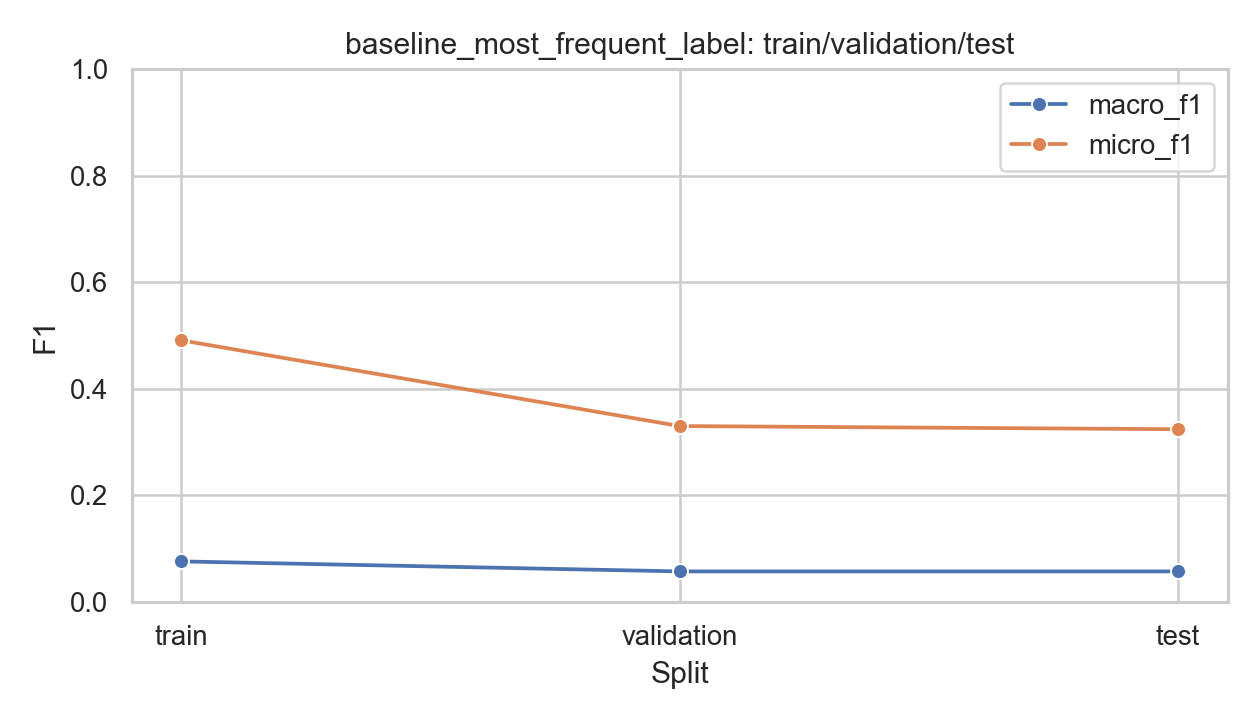

In [13]:
baseline_name = 'baseline_most_frequent_label'
most_frequent = int(np.argmax(arrays['train']['y'].sum(axis=0)))
most_frequent_article = pu.ARTICLE_CODES[most_frequent]

baseline_pred = {}
for split in pu.SPLIT_ORDER:
    pred = np.zeros_like(arrays[split]['y'])
    pred[:, most_frequent] = 1
    baseline_pred[split] = pred

baseline_metrics = extended_metrics_for_model(arrays, baseline_pred, baseline_name)
model_results[baseline_name] = baseline_metrics
model_predictions[baseline_name] = baseline_pred
print(f'Articulo constante predicho: {most_frequent_article}')
display_model_report(baseline_name, baseline_metrics)


#### 3.6.2 Modelo 2: TF-IDF + regresion logistica One-vs-Rest

Modelo principal del proyecto. Se evalua con umbral global 0.5 y con umbrales ajustados por articulo en validation. La segunda variante es la que se conserva para auditoria y explicabilidad.

,article_code,threshold
0,2,0.65
1,3,0.65
2,5,0.60
3,6,0.45
4,8,0.60
5,9,0.40
6,10,0.60
7,11,0.50
8,14,0.55
9,P1-1,0.55


,model,split,macro_f1,micro_f1
0,tfidf_logreg_threshold_tuned,train,0.876577,0.905152
1,tfidf_logreg_threshold_tuned,validation,0.739720,0.774359
2,tfidf_logreg_threshold_tuned,test,0.713807,0.751799


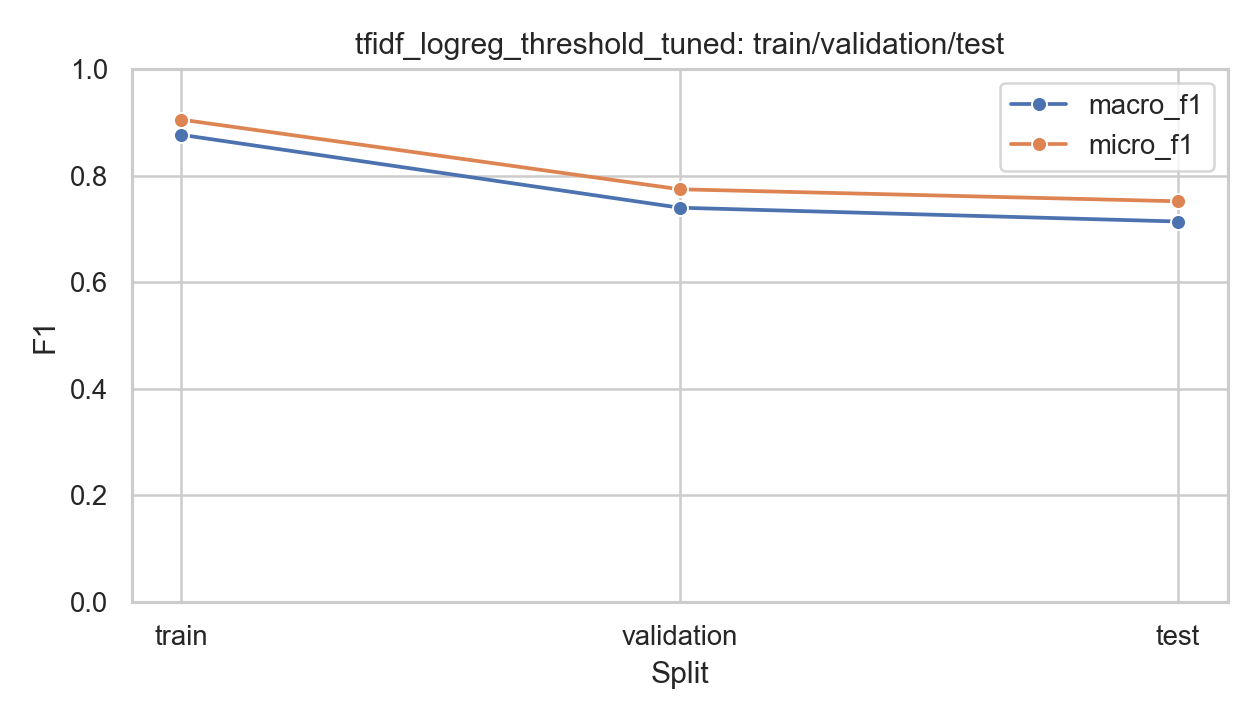

In [14]:
logreg = train_or_load_logreg(matrices['train'], arrays['train']['y'], retrain=RETRAIN_MODELS)
logreg_scores = {split: pu.as_probability_matrix(logreg.predict_proba(matrices[split])) for split in pu.SPLIT_ORDER}
logreg_threshold_values = tune_thresholds(arrays['validation']['y'], logreg_scores['validation'])
MODEL_PATHS['thresholds'].write_text(
    json.dumps({'thresholds': {code: float(value) for code, value in zip(pu.ARTICLE_CODES, logreg_threshold_values)}}, indent=2, sort_keys=True),
    encoding='utf-8',
)

logreg_pred_05 = {split: (logreg_scores[split] >= 0.5).astype(int) for split in pu.SPLIT_ORDER}
logreg_pred_tuned = {split: (logreg_scores[split] >= logreg_threshold_values).astype(int) for split in pu.SPLIT_ORDER}

logreg_05_metrics = extended_metrics_for_model(arrays, logreg_pred_05, 'tfidf_logreg_0.5', logreg_scores)
logreg_tuned_metrics = extended_metrics_for_model(arrays, logreg_pred_tuned, 'tfidf_logreg_threshold_tuned', logreg_scores)
logreg_metrics = pd.concat([logreg_05_metrics, logreg_tuned_metrics], ignore_index=True)

model_results['tfidf_logreg_0.5'] = logreg_05_metrics
model_results['tfidf_logreg_threshold_tuned'] = logreg_tuned_metrics
model_predictions['tfidf_logreg_0.5'] = logreg_pred_05
model_predictions['tfidf_logreg_threshold_tuned'] = logreg_pred_tuned
model_scores['tfidf_logreg_threshold_tuned'] = logreg_scores

thresholds = pd.DataFrame({'article_code': pu.ARTICLE_CODES, 'threshold': logreg_threshold_values})

display(thresholds)
display_model_report('tfidf_logreg_threshold_tuned', logreg_tuned_metrics)


#### 3.6.3 Modelo 3: TF-IDF + SVM lineal One-vs-Rest

Comparador lineal fuerte para texto disperso. La SVM aporta scores de margen para ROC/PR, aunque no probabilidades calibradas como la regresion logistica.

,model,split,macro_f1,micro_f1
0,tfidf_linear_svm,train,0.989904,0.991059
1,tfidf_linear_svm,validation,0.718870,0.789751
2,tfidf_linear_svm,test,0.749354,0.786677


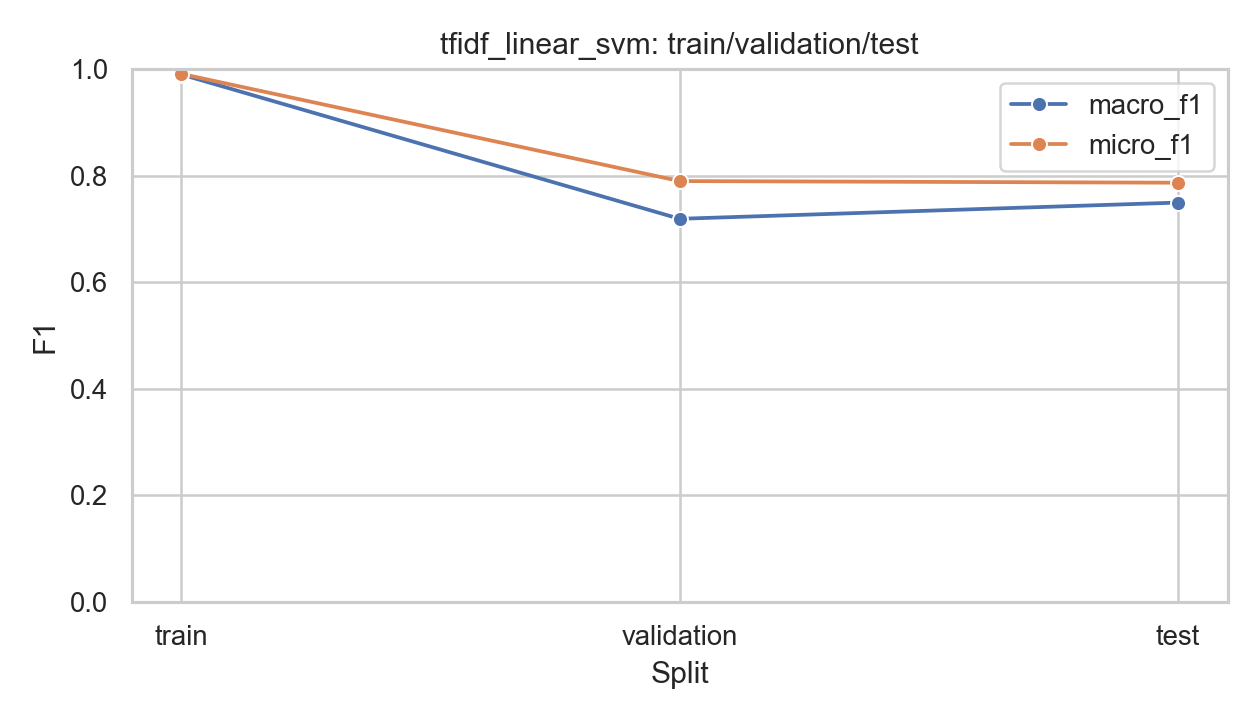

In [15]:
svm = train_or_load_svm(matrices['train'], arrays['train']['y'], retrain=RETRAIN_MODELS)
svm_name = 'tfidf_linear_svm'
svm_pred = {split: svm.predict(matrices[split]) for split in pu.SPLIT_ORDER}
svm_scores = {split: score_svm(svm, matrices[split]) for split in pu.SPLIT_ORDER}
svm_metrics = extended_metrics_for_model(arrays, svm_pred, svm_name, svm_scores)
model_results[svm_name] = svm_metrics
model_predictions[svm_name] = svm_pred
model_scores[svm_name] = svm_scores
display_model_report(svm_name, svm_metrics)


#### 3.6.4 Modelo 4: TF-IDF + SVD + MLP

Comparador no lineal ligero. Reduce TF-IDF a componentes densos con SVD y entrena un MLP. De este modelo si que podemos obtener la pérdida por época.

,article_code,mlp_threshold
0,2,0.35
1,3,0.55
2,5,0.45
3,6,0.50
4,8,0.30
5,9,0.20
6,10,0.25
7,11,0.30
8,14,0.20
9,P1-1,0.20


,model,split,macro_f1,micro_f1
0,tfidf_svd_mlp_threshold_tuned,train,0.818884,0.874967
1,tfidf_svd_mlp_threshold_tuned,validation,0.735855,0.782115
2,tfidf_svd_mlp_threshold_tuned,test,0.728547,0.769989


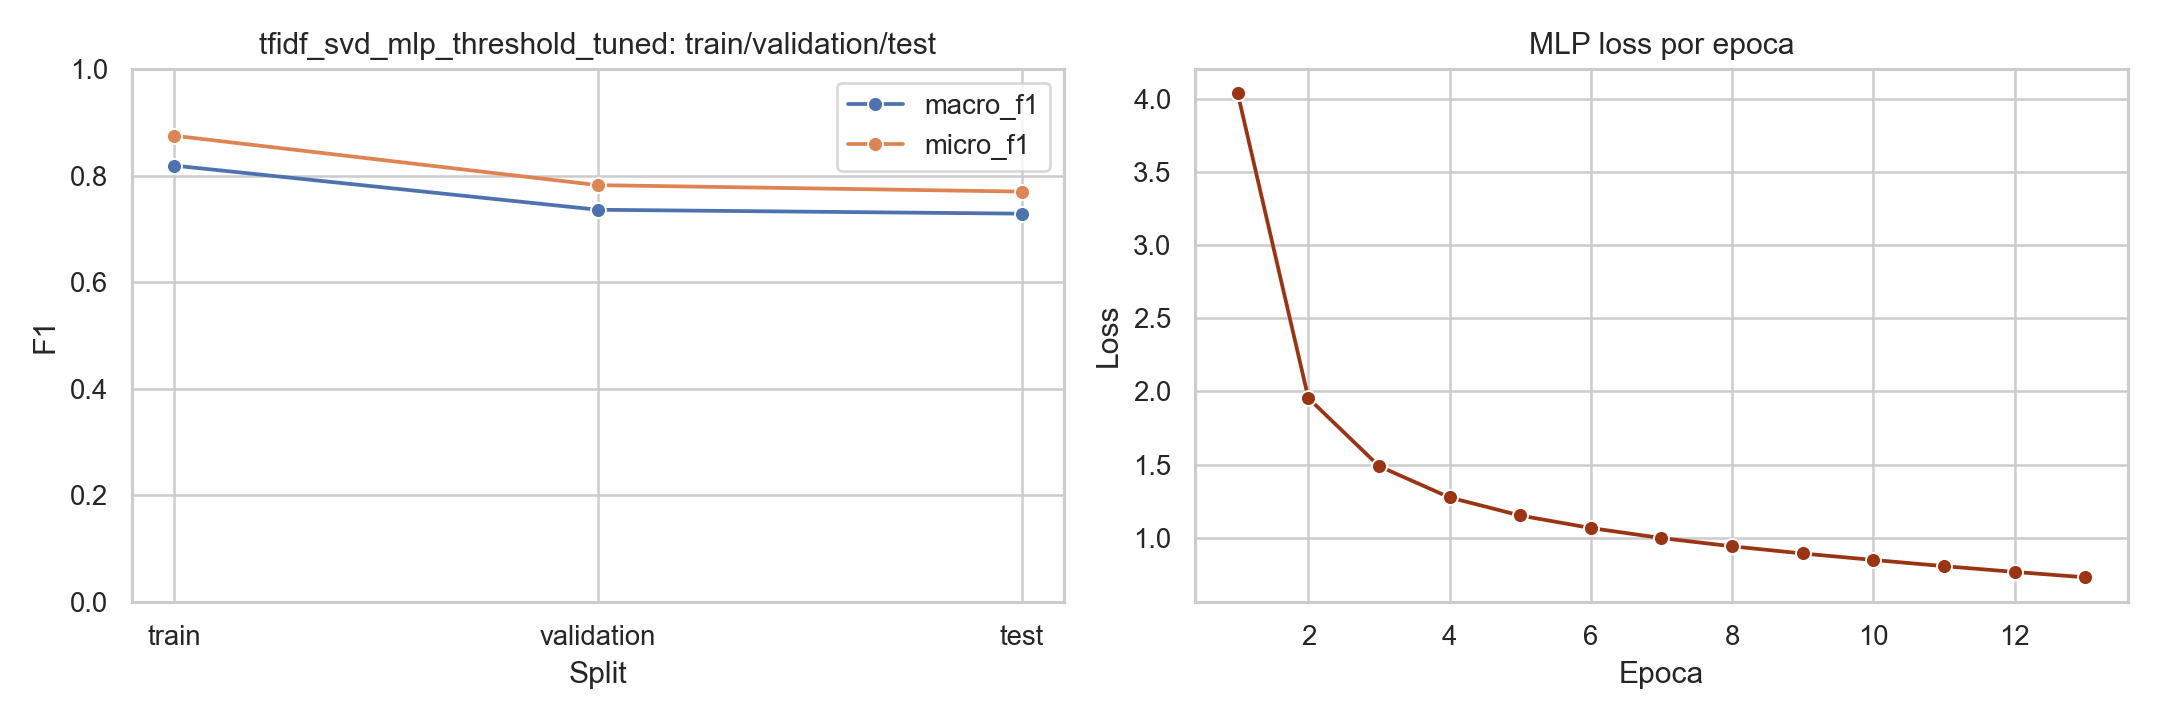

In [16]:
mlp_bundle = train_or_load_mlp(matrices['train'], arrays['train']['y'], retrain=RETRAIN_MODELS)
mlp_name = 'tfidf_svd_mlp_threshold_tuned'
mlp_scores = {split: score_mlp(mlp_bundle, matrices[split]) for split in pu.SPLIT_ORDER}
mlp_threshold_values = tune_thresholds(arrays['validation']['y'], mlp_scores['validation'])
mlp_pred = {split: (mlp_scores[split] >= mlp_threshold_values).astype(int) for split in pu.SPLIT_ORDER}
mlp_metrics = extended_metrics_for_model(arrays, mlp_pred, mlp_name, mlp_scores)
model_results[mlp_name] = mlp_metrics
model_predictions[mlp_name] = mlp_pred
model_scores[mlp_name] = mlp_scores

loss_curve = getattr(mlp_bundle['mlp'], 'loss_curve_', None)
mlp_training_curve = None if loss_curve is None else pd.DataFrame({'epoch': np.arange(1, len(loss_curve) + 1), 'loss': loss_curve})
display(pd.DataFrame({'article_code': pu.ARTICLE_CODES, 'mlp_threshold': mlp_threshold_values}))
display_model_report(mlp_name, mlp_metrics, training_curve=mlp_training_curve)


#### 3.6.5 Comparacion final validation/test

Se unifican los resultados. En pantalla solo se muestran macro-F1 y micro-F1 para validation/test; el CSV completo conserva metricas adicionales como Hamming loss, Jaccard, ROC-AUC y PR-AUC.

,model,split,macro_f1,micro_f1
11,tfidf_linear_svm,test,0.749354,0.786677
14,tfidf_svd_mlp_threshold_tuned,test,0.728547,0.769989
5,tfidf_logreg_0.5,test,0.714014,0.738337
8,tfidf_logreg_threshold_tuned,test,0.713807,0.751799
2,baseline_most_frequent_label,test,0.056528,0.323614
7,tfidf_logreg_threshold_tuned,validation,0.739720,0.774359
13,tfidf_svd_mlp_threshold_tuned,validation,0.735855,0.782115
10,tfidf_linear_svm,validation,0.718870,0.789751
4,tfidf_logreg_0.5,validation,0.717259,0.758431
1,baseline_most_frequent_label,validation,0.056528,0.329569


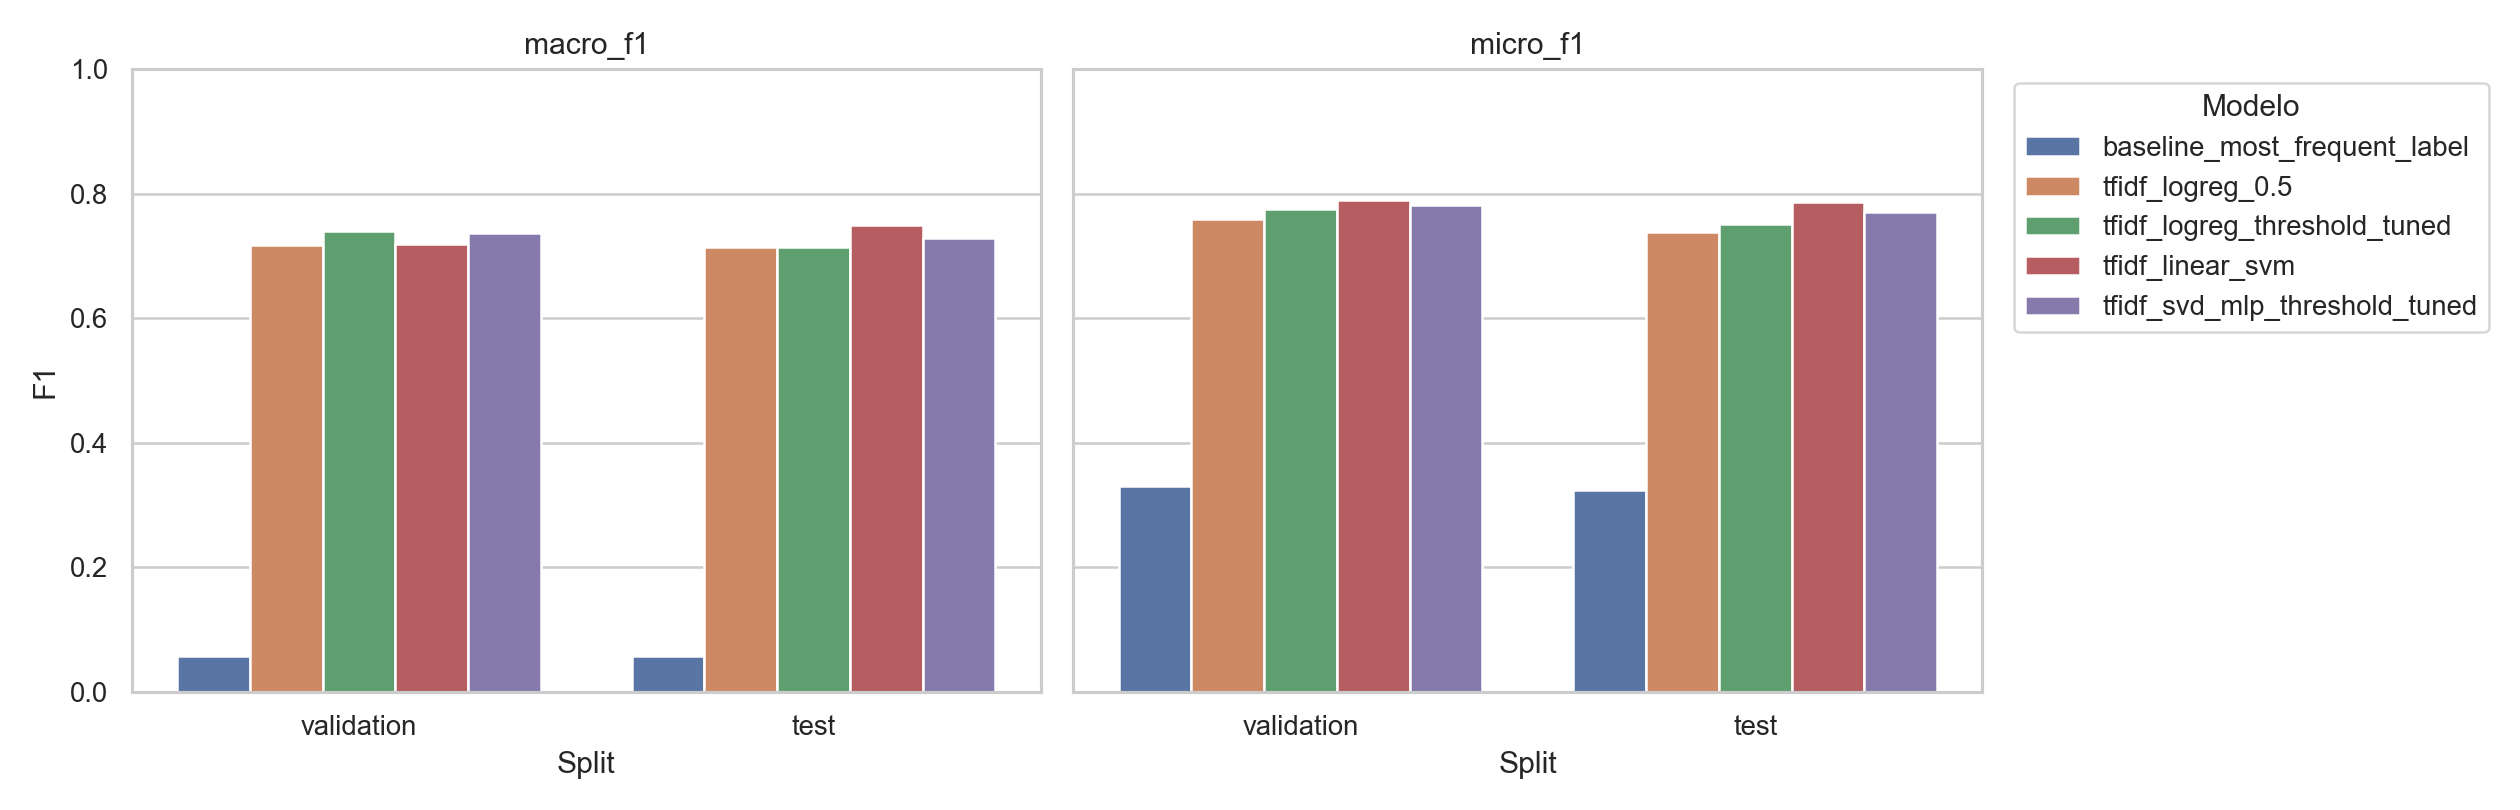

Artefactos guardados:
- vectorizer: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_tfidf_vectorizer.joblib
- logreg: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_logreg_ovr.joblib
- svm: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_svm_ovr.joblib
- mlp: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_svd_mlp.joblib
- thresholds: C:\Users\jordi\Documents\UNI\proyecto-aprendizaje-avanzado\artifacts\models\notebook_thresholds.json


In [17]:
comparison = pd.concat(model_results.values(), ignore_index=True)
comparison.to_csv(pu.METRICS / 'classification_model_comparison.csv', index=False)

paper_models = ['tfidf_logreg_threshold_tuned', 'tfidf_linear_svm', 'tfidf_svd_mlp_threshold_tuned']
paper = comparison[comparison['model'].isin(paper_models)].copy()
paper.to_csv(pu.METRICS / 'paper_classification_table.csv', index=False)
store_main_predictions(arrays, matrices, logreg, logreg_threshold_values, paper.to_dict(orient='records'))

comparison_report = comparison[comparison['split'].isin(['validation', 'test'])].copy()
comparison_report = comparison_report[['model', 'split', 'macro_f1', 'micro_f1']]
display(comparison_report.sort_values(['split', 'macro_f1'], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, metric in zip(axes, ['macro_f1', 'micro_f1']):
    sns.barplot(data=comparison_report, x='split', y=metric, hue='model', order=['validation', 'test'], ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('Split')
    ax.set_ylabel('F1')
    ax.set_ylim(0, 1)
axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
figure_path = pu.FIGURES / 'classification_macro_micro_comparison.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

print('Artefactos guardados:')
for name, path_obj in MODEL_PATHS.items():
    print(f'- {name}: {path_obj}')


## 3.7 Lectura de resultados

La comparacion no debe leerse como una carrera por una sola metrica. Macro-F1 penaliza fallar articulos escasos; micro-F1 resume rendimiento global. El baseline comprueba que no basta con predecir siempre el articulo 6. La SVM y el MLP sirven como contrastes: margen lineal fuerte y frontera no lineal ligera.

El modelo principal sigue siendo `tfidf_logreg_threshold_tuned` porque sus scores y coeficientes se pueden auditar mejor en los notebooks posteriores.

In [18]:
val_best = comparison[comparison['split'] == 'validation'].sort_values('macro_f1', ascending=False).iloc[0]
test_best = comparison[comparison['split'] == 'test'].sort_values('macro_f1', ascending=False).iloc[0]
main_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'tfidf_logreg_threshold_tuned')].iloc[0]
baseline_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'baseline_most_frequent_label')].iloc[0]
mlp_test = comparison[(comparison['split'] == 'test') & (comparison['model'] == 'tfidf_svd_mlp_threshold_tuned')].iloc[0]
print(f"Mejor validation macro-F1: {val_best['model']} ({val_best['macro_f1']:.3f})")
print(f"Mejor test macro-F1: {test_best['model']} ({test_best['macro_f1']:.3f})")


Mejor validation macro-F1: tfidf_logreg_threshold_tuned (0.740)
Mejor test macro-F1: tfidf_linear_svm (0.749)


## 4. Auditoria visual en test

Test se usa una vez que los modelos y umbrales ya estan fijados. Aqui no interesa imprimir matrices largas: se guardan completas en CSV y se muestran como heatmaps de falsos positivos y falsos negativos por articulo.

,model,macro_f1,micro_f1
11,tfidf_linear_svm,0.749354,0.786677
14,tfidf_svd_mlp_threshold_tuned,0.728547,0.769989
5,tfidf_logreg_0.5,0.714014,0.738337
8,tfidf_logreg_threshold_tuned,0.713807,0.751799
2,baseline_most_frequent_label,0.056528,0.323614


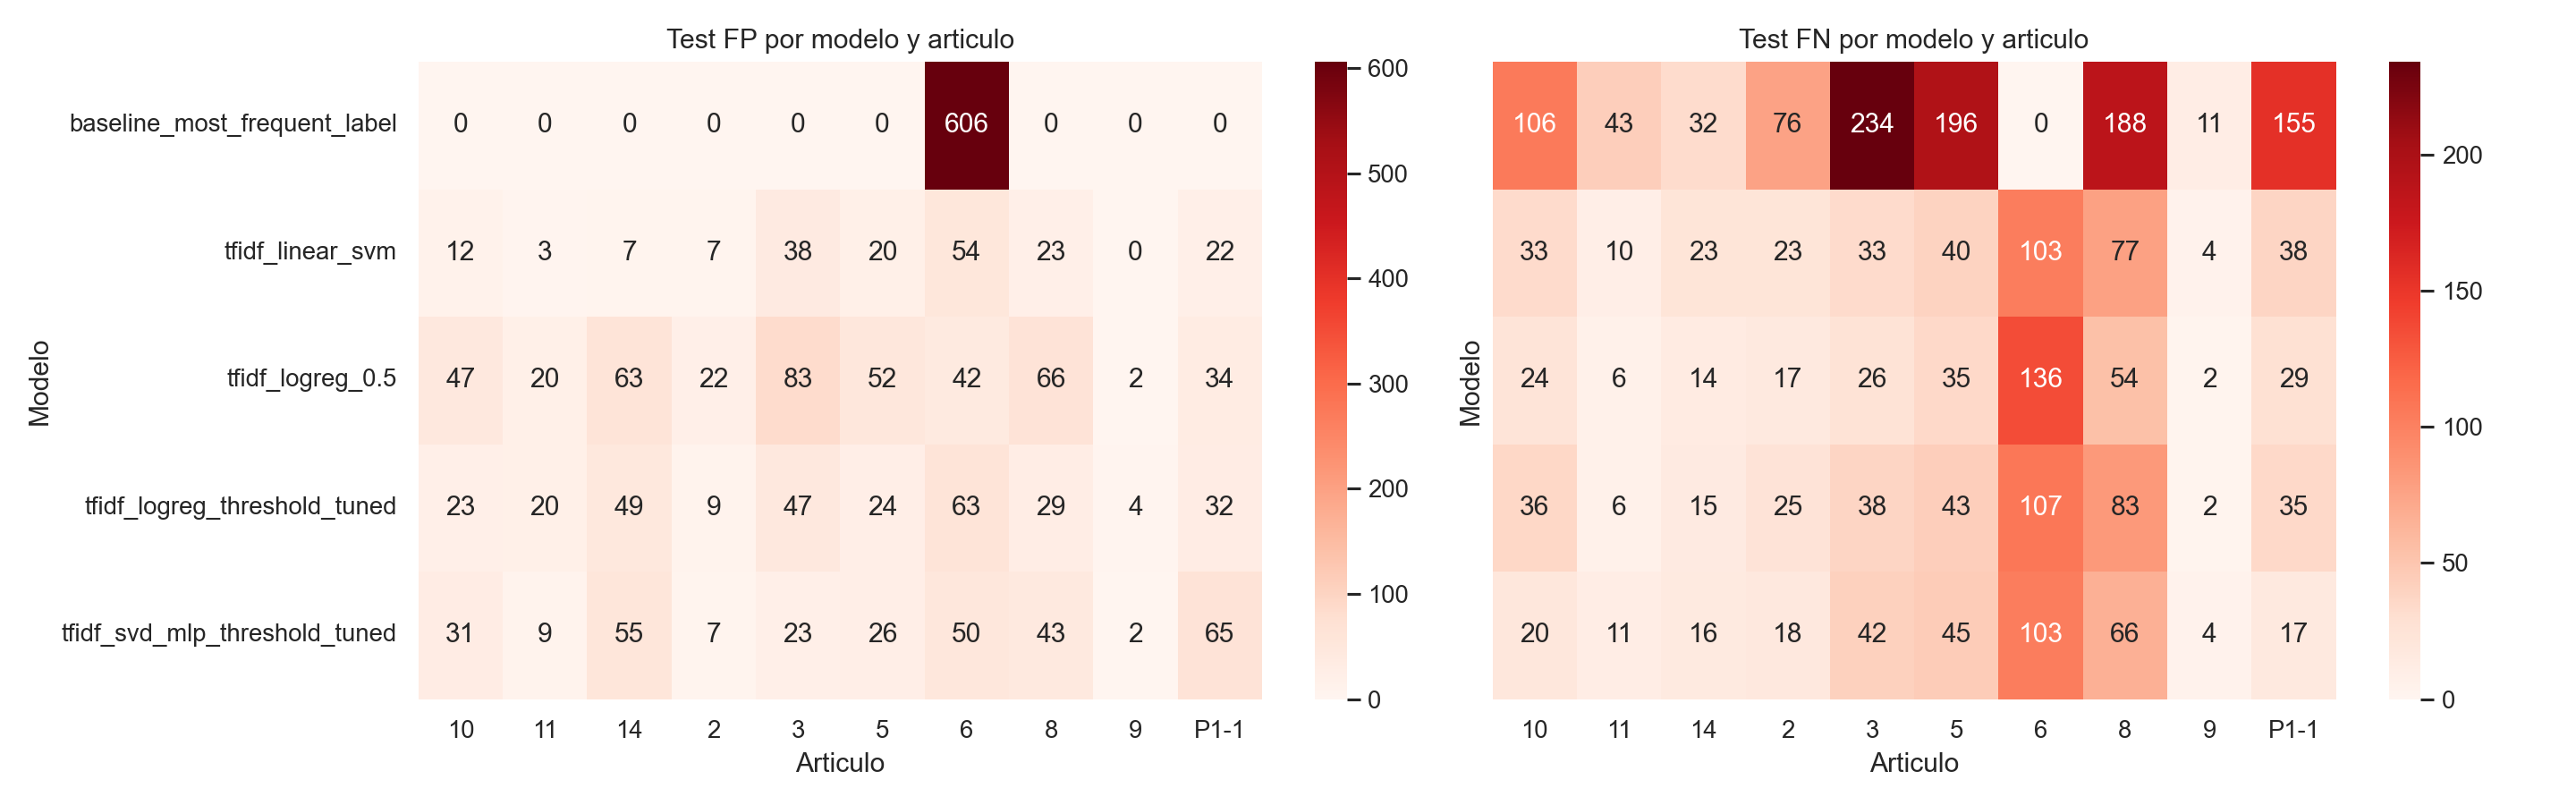

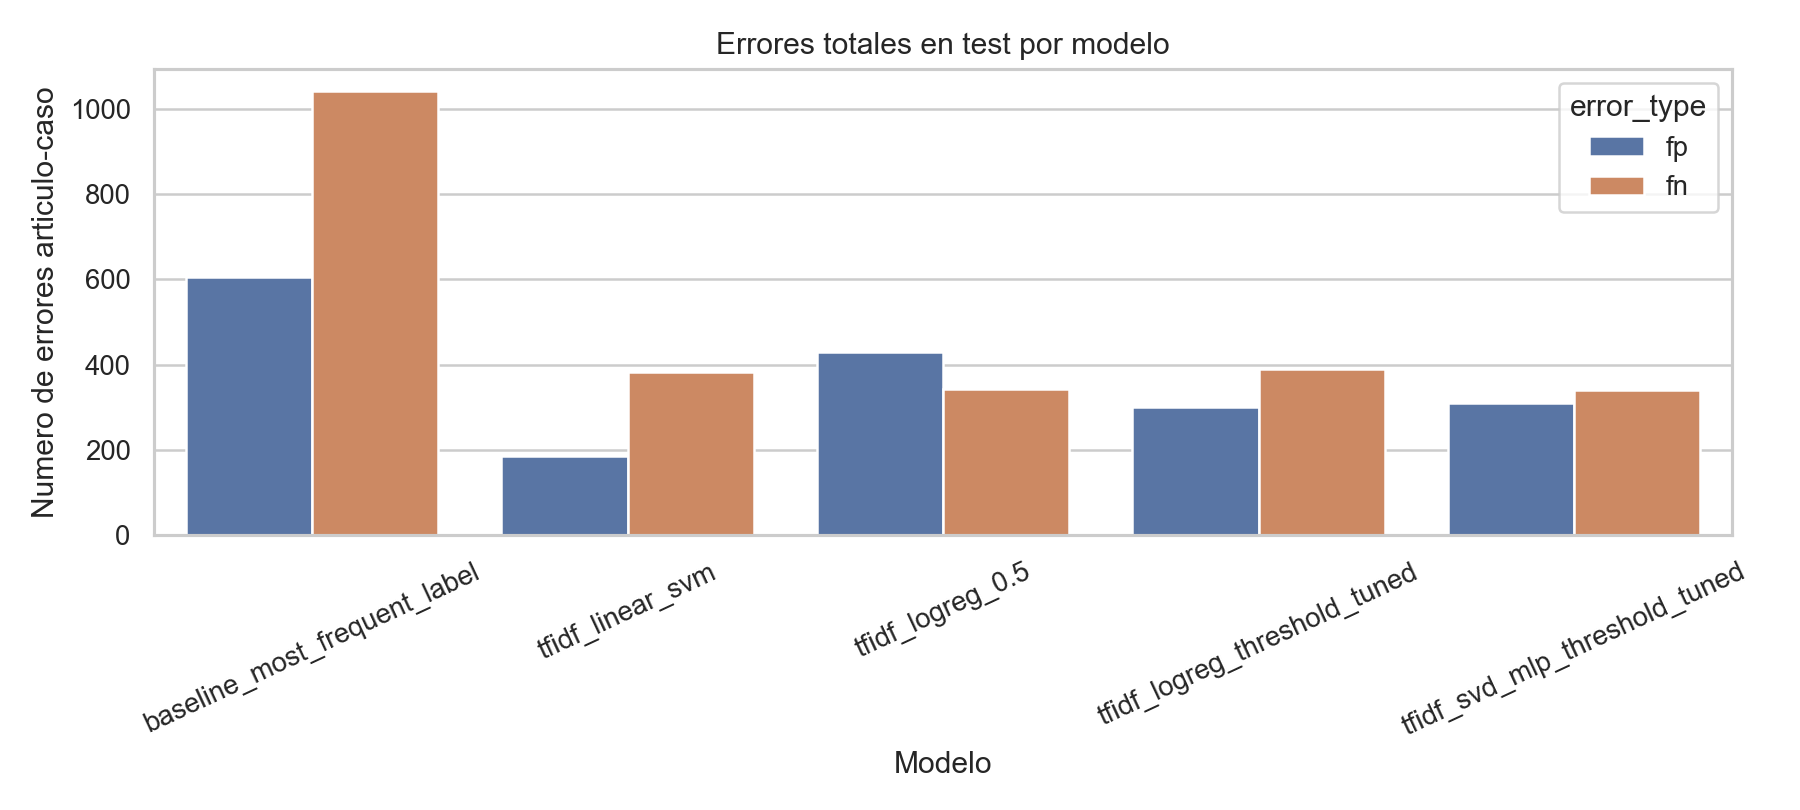

In [19]:
test_comparison = comparison[comparison['split'] == 'test'].sort_values('macro_f1', ascending=False)
display(test_comparison[['model', 'macro_f1', 'micro_f1']])

test_correspondence = pd.concat([
    correspondence_table(arrays['test']['y'], preds['test'], model_name, split='test')
    for model_name, preds in model_predictions.items()
], ignore_index=True)
test_correspondence.to_csv(pu.METRICS / 'classification_test_correspondence_matrix.csv', index=False)

error_heat = test_correspondence.melt(
    id_vars=['model', 'article_code'], value_vars=['fp', 'fn'],
    var_name='error_type', value_name='n_errors'
)
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, error_type in zip(axes, ['fp', 'fn']):
    pivot = error_heat[error_heat['error_type'] == error_type].pivot(index='model', columns='article_code', values='n_errors')
    sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title(f'Test {error_type.upper()} por modelo y articulo')
    ax.set_xlabel('Articulo')
    ax.set_ylabel('Modelo')
fig.tight_layout()
figure_path = pu.FIGURES / 'classification_test_error_correspondence.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))

error_totals = test_correspondence.groupby('model', as_index=False)[['fp', 'fn']].sum()
error_totals_long = error_totals.melt(id_vars='model', value_vars=['fp', 'fn'], var_name='error_type', value_name='n_errors')
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=error_totals_long, x='model', y='n_errors', hue='error_type', ax=ax)
ax.set_title('Errores totales en test por modelo')
ax.set_xlabel('Modelo')
ax.set_ylabel('Numero de errores articulo-caso')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
figure_path = pu.FIGURES / 'classification_test_error_totals.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))


## 5. Curvas ROC y Precision-Recall con Matplotlib

Las curvas se dibujan directamente dentro del notebook con `matplotlib`. Se calculan sobre scores continuos, no sobre etiquetas ya umbralizadas. Por eso se comparan LogReg, SVM y MLP; el baseline constante queda fuera porque no ordena casos por confianza.

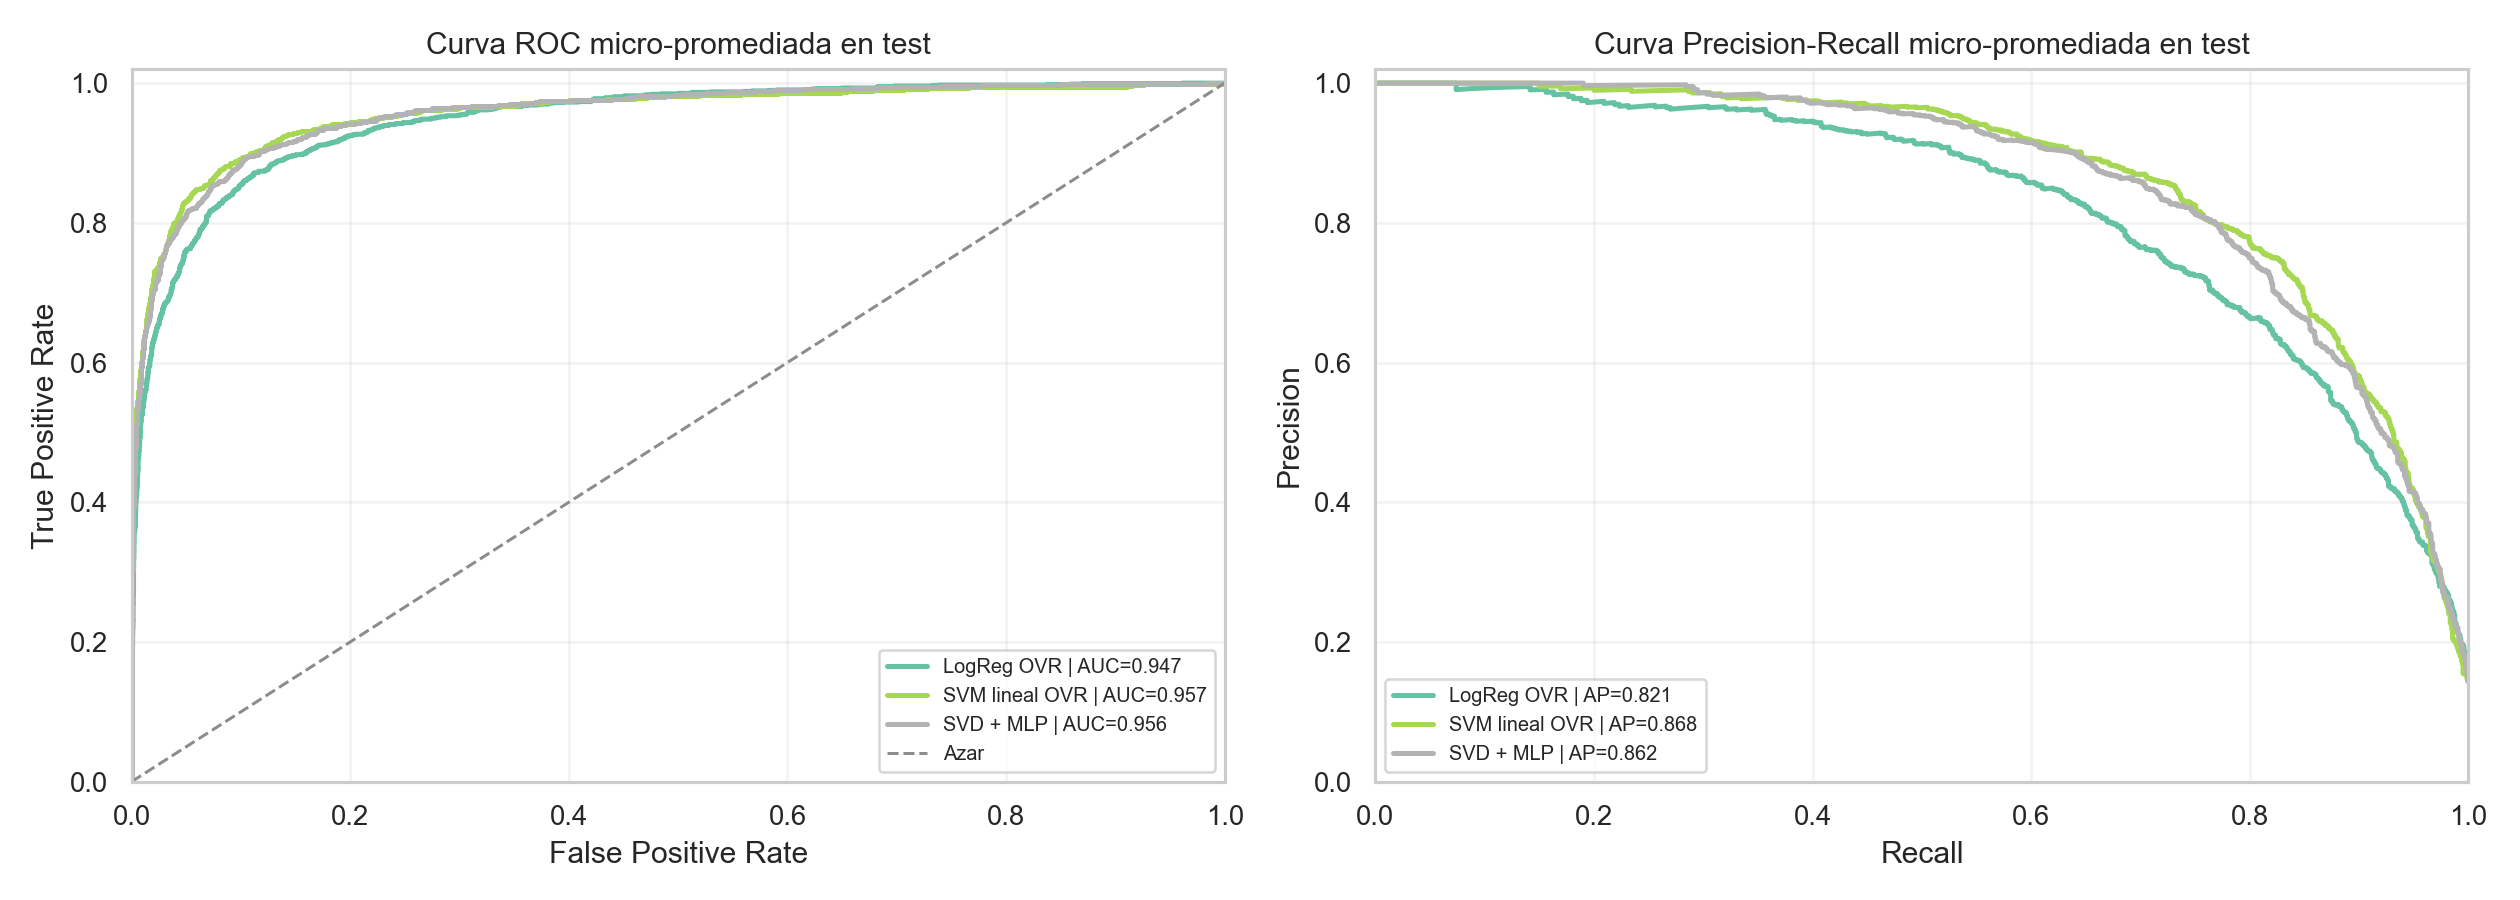

In [20]:
score_models_for_curves = {
    'LogReg OVR': model_scores['tfidf_logreg_threshold_tuned']['test'],
    'SVM lineal OVR': model_scores['tfidf_linear_svm']['test'],
    'SVD + MLP': model_scores['tfidf_svd_mlp_threshold_tuned']['test'],
}
y_test = arrays['test']['y']

roc_pr_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(score_models_for_curves)))

for color, (model_name, scores) in zip(colors, score_models_for_curves.items()):
    fpr, tpr, _ = roc_curve(y_test.ravel(), scores.ravel())
    precision, recall, _ = precision_recall_curve(y_test.ravel(), scores.ravel())

    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall, precision)
    roc_pr_rows.append({
        'model': model_name,
        'split': 'test',
        'roc_auc_micro_curve': float(roc_auc),
        'pr_auc_micro_curve': float(pr_auc),
    })

    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{model_name} | AUC={roc_auc:.3f}')
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{model_name} | AP={pr_auc:.3f}')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='0.55', linewidth=1.2, label='Azar')
axes[0].set_title('Curva ROC micro-promediada en test')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend(loc='lower right', fontsize=8)

axes[1].set_title('Curva Precision-Recall micro-promediada en test')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)
axes[1].legend(loc='lower left', fontsize=8)

fig.tight_layout()
roc_pr_figure_path = pu.FIGURES / 'classification_test_roc_pr_curves.png'
fig.savefig(roc_pr_figure_path, dpi=180)
plt.close(fig)

display(IPImage(filename=str(roc_pr_figure_path)))

roc_pr_summary = pd.DataFrame(roc_pr_rows)
roc_pr_summary.to_csv(pu.METRICS / 'classification_test_roc_pr_summary.csv', index=False)


## 6. Esquema visual: de texto a matrices X/Y

**Lectura del esquema.** Los textos reales entran al vectorizador TF-IDF, que construye la matriz `X`: filas = casos, columnas = terminos/bigramas, valores = pesos TF-IDF. En paralelo, las etiquetas reales forman la matriz `Y`: filas = los mismos casos, columnas = articulos, valores = 0/1. El modelo aprende a aproximar `Y` desde `X` y despues convierte scores en decisiones mediante umbrales.

## 7. Interpretacion compacta de metricas

En pantalla se priorizan `macro_f1` y `micro_f1`. `macro_f1` detecta fallos en articulos escasos; `micro_f1` resume el rendimiento global. Otras metricas se guardan en CSV y se usan en figuras especificas: ROC/PR para ranking de scores y TP/FP/FN/TN para auditoria de errores.

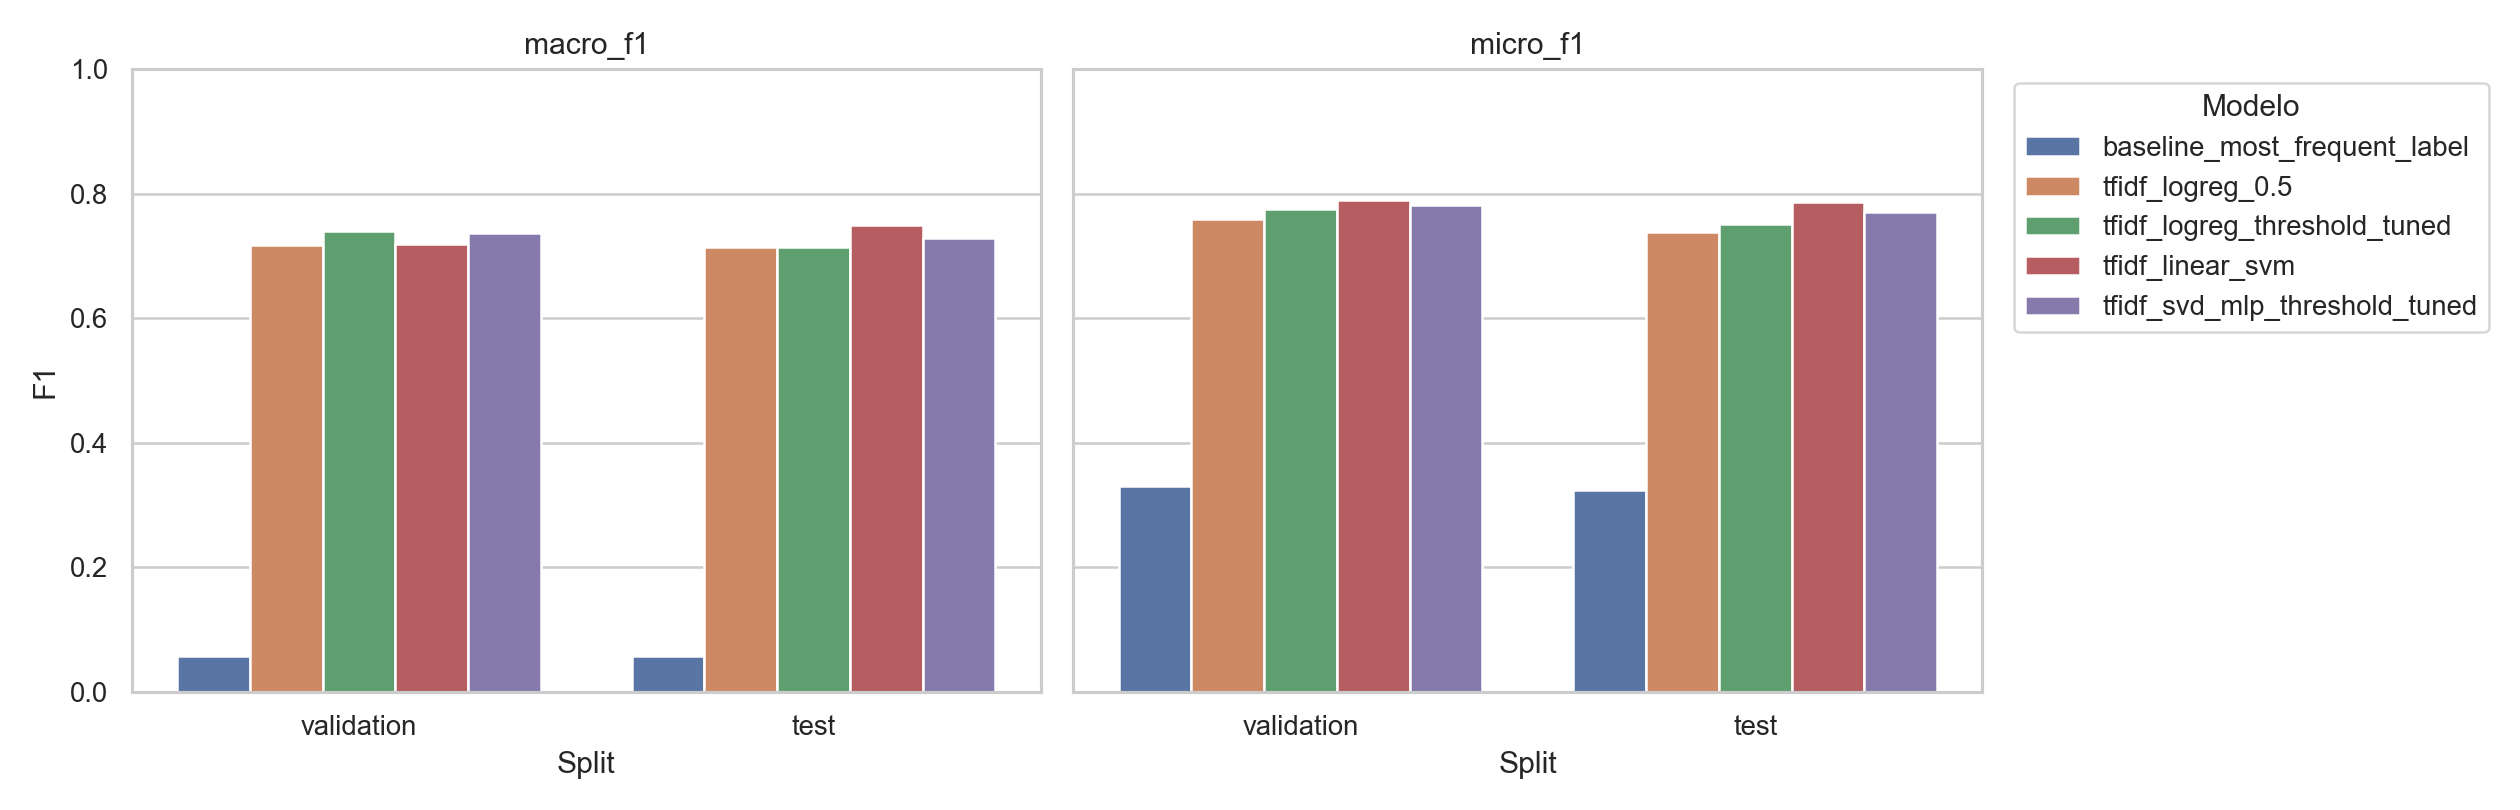

In [21]:
metric_plot_df = comparison[comparison['split'].isin(['validation', 'test'])].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, metric in zip(axes, ['macro_f1', 'micro_f1']):
    sns.barplot(data=metric_plot_df, x='split', y=metric, hue='model', order=['validation', 'test'], ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('Split')
    ax.set_ylabel('F1')
    ax.set_ylim(0, 1)
axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
figure_path = pu.FIGURES / 'model_comparison_metrics.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))


## 8. Ejemplos reales de prediccion

Se leen las predicciones guardadas en SQLite para el modelo principal. La tabla se mantiene pequena: etiquetas reales, etiquetas predichas y score maximo para casos de test.

In [22]:
pred = pu.load_predictions('notebook_threshold_tuned')
def decode(row, field):
    return ', '.join([code for code, value in zip(pu.ARTICLE_CODES, row[field]) if value]) or '(ninguno)'
sample = pred[pred['split']=='test'].head(8).copy()
sample['true_articles'] = sample.apply(lambda r: decode(r,'y_true'), axis=1)
sample['pred_articles'] = sample.apply(lambda r: decode(r,'y_pred'), axis=1)
sample['max_score'] = sample['scores'].map(lambda xs: max(xs) if xs else np.nan)
display(sample[['case_id','true_articles','pred_articles','max_score']])
display(pd.DataFrame([pu.summarize_case(sample.iloc[0]['case_id'], max_chars=1000)]))


,case_id,true_articles,pred_articles,max_score
0,ecthr_task_b_test_000000,10,"8, 10",0.949734
1,ecthr_task_b_test_000001,8,6,0.607172
2,ecthr_task_b_test_000002,6,6,0.624944
3,ecthr_task_b_test_000003,6,6,0.790289
4,ecthr_task_b_test_000004,"3, 6",3,0.965156
5,ecthr_task_b_test_000005,3,"3, 8",0.967893
6,ecthr_task_b_test_000006,6,6,0.564444
7,ecthr_task_b_test_000007,3,3,0.984210


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000000,ecthr_task_b,test,None,37,4774,"5. The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens Næringsliv (“DN”), published by the company DN Nye Medier AS. 6. On 23...",10


## 9. Figura resumen de resultados y umbrales

Esta figura junta lo que se quiere leer rapido: macro-F1, micro-F1 y los umbrales aprendidos por articulo para el modelo principal.

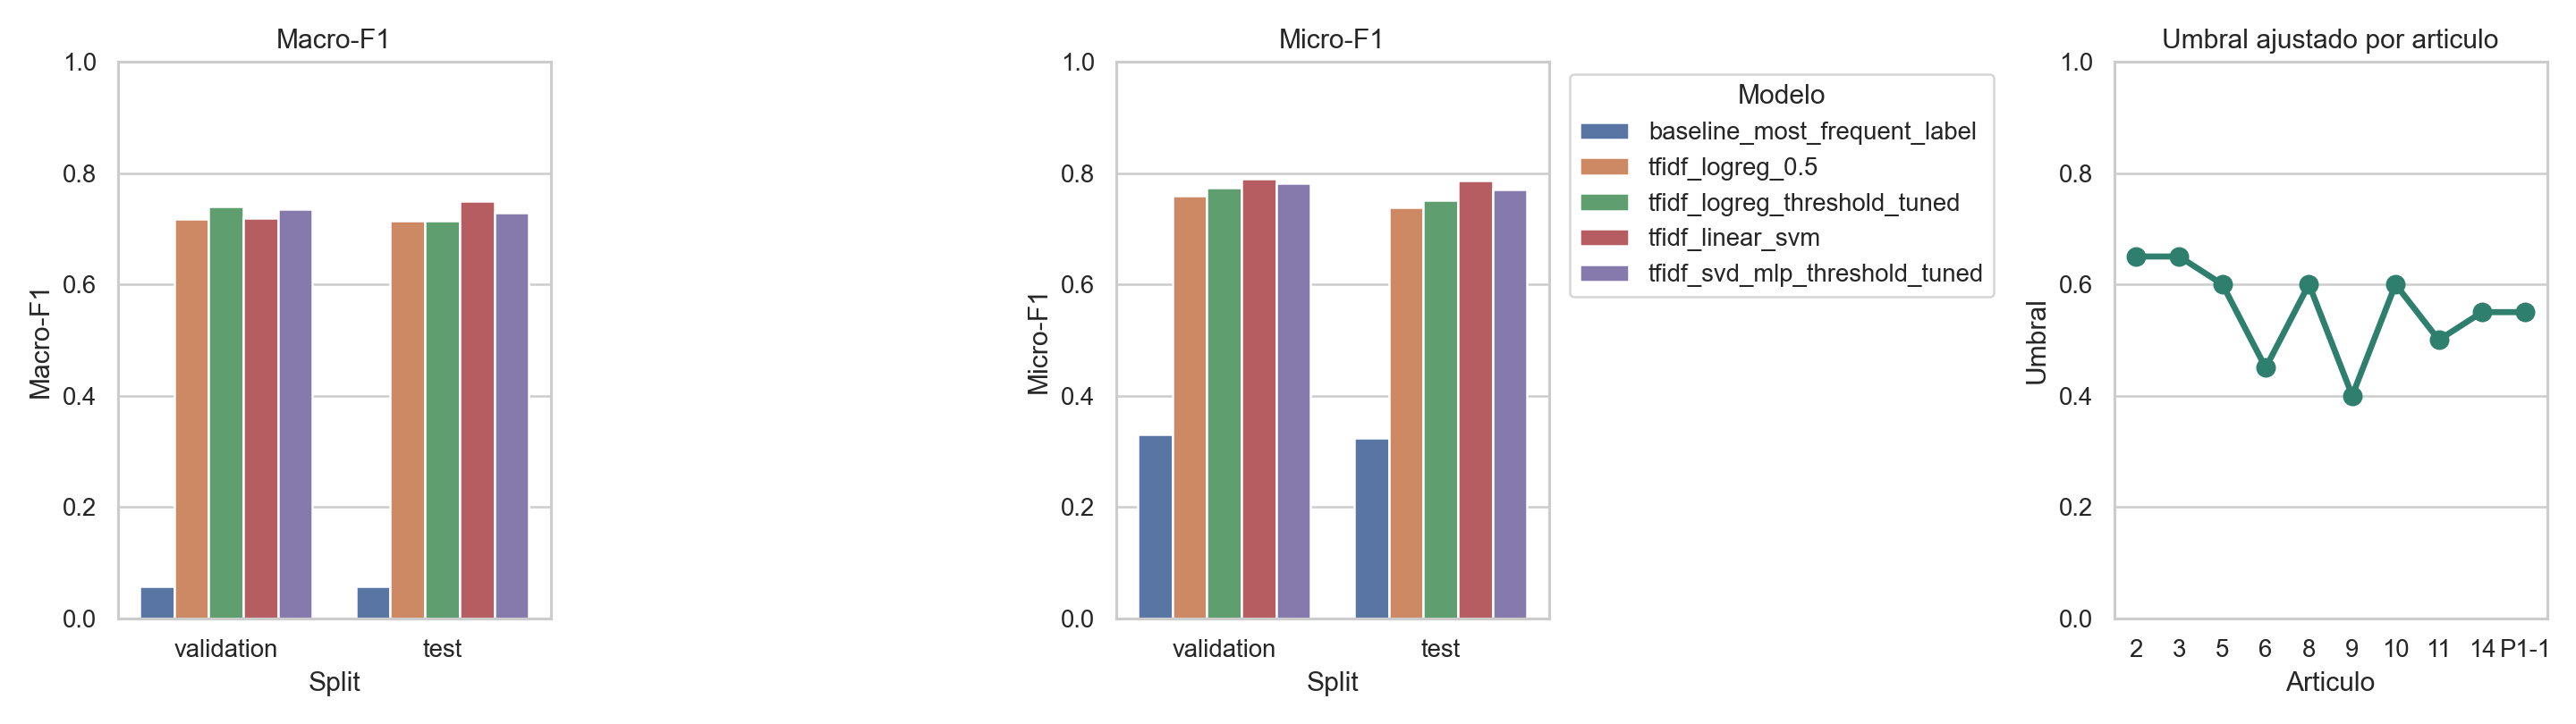

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_df = comparison[comparison['split'].isin(['validation', 'test'])].copy()

sns.barplot(data=plot_df, x='split', y='macro_f1', hue='model', order=['validation', 'test'], ax=axes[0])
axes[0].set_title('Macro-F1')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Macro-F1')

sns.barplot(data=plot_df, x='split', y='micro_f1', hue='model', order=['validation', 'test'], ax=axes[1])
axes[1].set_title('Micro-F1')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Micro-F1')

sns.pointplot(data=thresholds, x='article_code', y='threshold', ax=axes[2], color='#2f7f6f')
axes[2].set_title('Umbral ajustado por articulo')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Articulo')
axes[2].set_ylabel('Umbral')
axes[2].tick_params(axis='x', rotation=0)

axes[0].legend_.remove()
axes[1].legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
figure_path = pu.FIGURES / 'fig04_modeling_and_thresholds.png'
fig.savefig(figure_path, dpi=180)
plt.close(fig)
display(IPImage(filename=str(figure_path)))


## 10. Resultado del notebook

Quedan modelos en `artifacts/models/`, tablas completas en `artifacts/metrics/`, figuras en `artifacts/figures/` y predicciones por caso en SQLite para el notebook 04. La lectura principal del notebook queda basada en graficas y tablas cortas.